In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os

from codes.Quantum import *
from codes.CSPSA import *

import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt

In [13]:
def obj_fun( m , Psi ):
    mkron = MKron( m )
    return Infidelity( mkron, Psi )

def postprocessing( x ):
    return x/np.linalg.norm(x)

In [14]:
gains = [3, 0, 0.1, 0.602, 0.101]
max_iter = 100
max_rep = 1000
Out = []
iter = np.linspace(0.0, 0.5, 6)

Out = np.empty((max_rep,max_iter))

for i in range(6):
    a = i/10
    for k in range(max_rep):
        psi = np.sqrt(a)*np.array([1, 0, 0, 0]) + np.sqrt(1-a)*np.array([0, 0, 0, 1])
        psi = triple_kron(psi, psi, psi)
        measure = RandomState( 4 )
        cspsa = CSPSA(gains=gains)
        obj_fun( measure, psi)

        results = cspsa.minimizev2(psi, obj_fun, measure, max_iter, postprocessing=postprocessing )
        infidelities = results.fun

        Out[k, :] = infidelities
    
    np.save("Data_sim_0"+str(i), Out)

In [17]:
for i in range(6):
    a = i/10
    psi = np.sqrt(a)*np.array([1, 0, 0, 0]) + np.sqrt(1-a)*np.array([0, 0, 0, 1])
    print(psi)

[0. 0. 0. 1.]
[0.31622777 0.         0.         0.9486833 ]
[0.4472136  0.         0.         0.89442719]
[0.54772256 0.         0.         0.83666003]
[0.63245553 0.         0.         0.77459667]
[0.70710678 0.         0.         0.70710678]


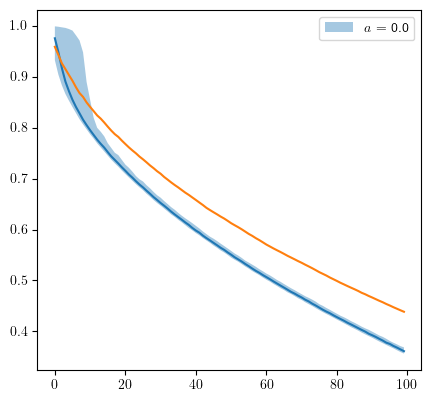

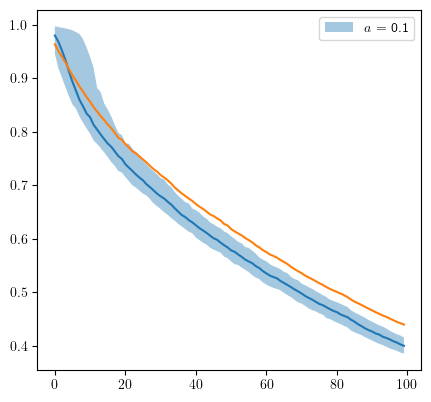

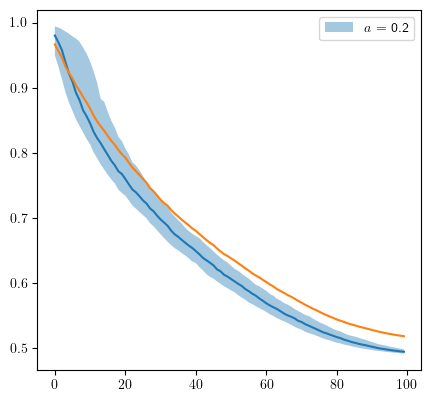

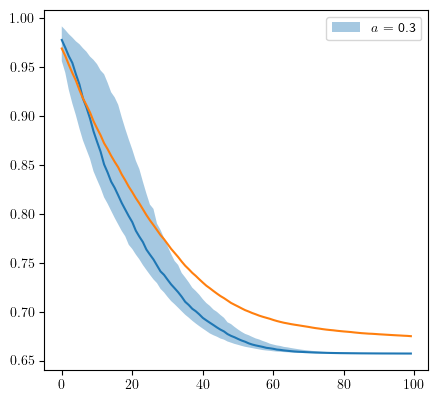

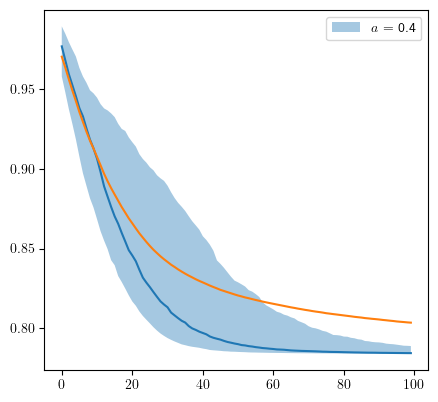

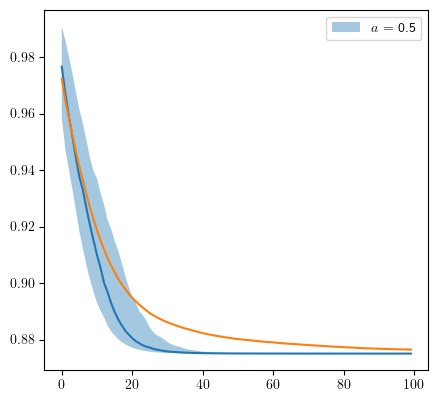

In [16]:
#os.chdir('data_schmidt_states')

for i in range(6):
    a = i/10
    max_iter = 100
    name01 = "Data_sim_0"+str(i)+".npy"
    name02 = "sim_schmidt_"+str(a)+".pdf"
    Inf = np.load(name01)
    Median = np.median(Inf, axis = 0)
    Mean = np.mean(Inf, axis = 0)
    Q1 = np.percentile(Inf, 25, axis = 0)
    Q3 = np.percentile(Inf, 75, axis = 0)


    fig = plt.figure()
    ax = fig.add_axes([0.1, 0.1, 0.6, 0.75])

    ax.plot(Median)
    ax.plot(Mean)
    ax.fill_between(range(max_iter),Q1,Q3, alpha=0.4, label = r"$a$ = 0."+str(i))
    
    plt.savefig(name02)
    plt.legend()
    plt.show()